In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\aabhi\OneDrive\Desktop\cyberbullyingdetection\labeled_data.csv")
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [2]:
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [3]:
df['label'] = df['class'].apply(lambda x: 0 if x == 2 else 1)

In [4]:
df = df.rename(columns={"tweet": "text"})
df = df[['text', 'label']]
df.head()

,text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,0
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    
    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # remove mentions & hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    
    # remove numbers & special chars
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    # remove stopwords + stemming
    words = [ps.stem(w) for w in words if w not in stop_words]
    
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aabhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df['clean_text'] = df['text'].apply(clean_text)
df.head()

,text,label,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,0,rt woman complain clean hous amp man alway tak...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1,rt boy dat cold tyga dwn bad cuffin dat hoe st...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1,rt dawg rt ever fuck bitch start cri confus shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1,rt look like tranni
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1,rt shit hear might true might faker bitch told ya


In [7]:
df = df[df['clean_text'].str.strip() != ""]

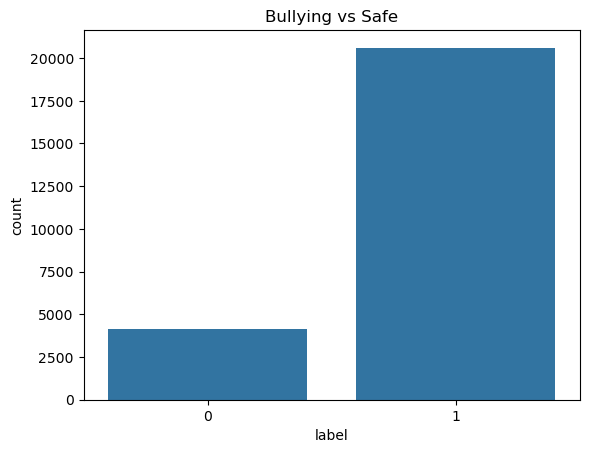

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Bullying vs Safe")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.949121744397335
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       833
           1       0.96      0.98      0.97      4120

    accuracy                           0.95      4953
   macro avg       0.92      0.89      0.91      4953
weighted avg       0.95      0.95      0.95      4953



In [13]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))